graph api vs functional api

component of langgraph
nodes
edges
state

Build A Basic Chatbot With Langgraph(GRAPH API)

In [43]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages#reducers

In [44]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [45]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [46]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [47]:
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7613ec7807d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7613ec782850>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [48]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7613ec776b10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7613ec7763f0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [49]:
 ## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [50]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

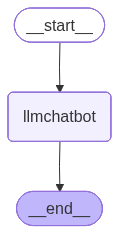

In [51]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [52]:
graph.invoke("hi")

InvalidUpdateError: Expected dict, got hi
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [53]:
response=graph.invoke({"messages":"hi"})
response

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='e4b8bf3f-fb40-4311-961c-ff2b0c9fde8d'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.054495343, 'completion_tokens_details': None, 'prompt_time': 0.003479703, 'prompt_tokens_details': None, 'queue_time': 0.283994857, 'total_time': 0.057975046}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee133-f798-7373-b691-6baae0e1395e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [54]:
response["messages"]

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='e4b8bf3f-fb40-4311-961c-ff2b0c9fde8d'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.054495343, 'completion_tokens_details': None, 'prompt_time': 0.003479703, 'prompt_tokens_details': None, 'queue_time': 0.283994857, 'total_time': 0.057975046}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee133-f798-7373-b691-6baae0e1395e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

In [55]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [ ]:
for event in graph.stream({"messages":"Hi How are you?"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 40, 'total_tokens': 99, 'completion_time': 0.139424997, 'completion_tokens_details': None, 'prompt_time': 0.01028162, 'prompt_tokens_details': None, 'queue_time': 0.332344199, 'total_time': 0.149706617}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee136-2204-7b42-81d0-5df5af971a30-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 59, 'total_tokens': 99})]}} /////////////////////////////////////


In [58]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?


# Chatbot With Tool

In [61]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agent

In [62]:
## Custom function
 
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [63]:
tools=[tool,multiply]#tool is defined in tavily search

In [64]:
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7613ec776b10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7613ec7763f0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you

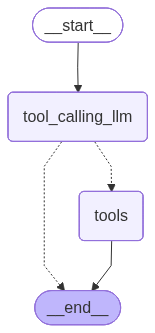

In [65]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
 
## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [66]:
response=graph.invoke({"messages":"what is the latest ai news"})
response['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.7511561, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "IN TODAY’S NEWSLETTER:\\n\\n- Jeff Bezos predicts AI will create a labor shortage, not replace human workers across the economy\\n\\n- OpenAI faces multistate investigation into data handling and chatbot behavior\\n\\n- AI-designed \'universal vaccine\' passes first human clinical trial, could prevent future pandemics\\n\\nWORK IN PROGRESS: Amazon founder Jeff Bezos said the rise of artificial intelligence (AI) won\'t lead to the replacement of humans in the workforce and will instead create labor shortages.\\n\\nSam Altman, chief executive officer of OpenAI, during a panel session on day three of the World Economic Forum (WEF) in Davos, Switzerlan

In [67]:
for m in response['messages']:
    m.pretty_print()
    

================================ Human Message =================================

what is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hrawn235y)
 Call ID: hrawn235y
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.7511561, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "IN TODAY’S NEWSLETTER:\n\n- Jeff Bezos predicts AI will create a labor shortage, not replace human workers across the economy\n\n- OpenAI faces multistate investigation into data handling and chatbot behavior

In [68]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (mvnxy1fjk)
 Call ID: mvnxy1fjk
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [69]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})#two tools called only the first one get executed
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (r2y3m5rs6)
 Call ID: r2y3m5rs6
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
  multiply (4nhy2nf2a)
 Call ID: 4nhy2nf2a
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/06/12/ai-tech-brief-wall-street-rewrites-rules-ai-giants/", "title": "AI & Tech Brief: Wall Street rewrites rules for AI giants - The Washington Post", "score": 0.64746445, "published_date": "Fri, 12 Jun 2026 19:29:38 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Wall Street

# ReAct Agent Architecture

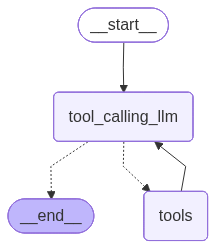

In [70]:
# Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [71]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rab2ajtc6)
 Call ID: rab2ajtc6
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
  multiply (8mjtjtvnk)
 Call ID: 8mjtjtvnk
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bloomberg.com/news/articles/2026-06-19/lutnick-s-anthropic-crackdown-claims-new-power-over-ai-models", "title": "Lutnick’s Anthropic Crackdown Claims New Power Over AI Models - Bloomberg.com", "score": 0.68064564, "published_date": "Fri, 19 Jun 2026 12:00:00 GMT", "content": "# Lutnick’s Anthropic Crackdown Claims New Power Over AI Mode

Adding Memory In Agentic Graph

In [72]:
response=graph.invoke({"messages":"Hello my name is saumyapraksh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is saumyapraksh
================================== Ai Message ==================================

Hello Saumya Prakash, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [73]:
response=graph.invoke({"messages":"what is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have the ability to know your personal details or identity. If you'd like to share your name with me, I'd be happy to chat with you and get to know you better.


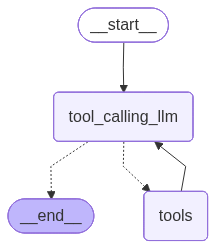

In [74]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() #memory saver at each check point

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [75]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is saumya prakash"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is saumya prakash', additional_kwargs={}, response_metadata={}, id='10f89282-caa8-493d-abe9-c47c11fe4761'),
  AIMessage(content="Hello Saumya Prakash! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 1754, 'total_tokens': 1784, 'completion_time': 0.079922883, 'completion_tokens_details': None, 'prompt_time': 0.233173231, 'prompt_tokens_details': None, 'queue_time': 0.161425359, 'total_time': 0.313096114}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee138-0e15-7ba2-b92b-9e3459e50601-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1754, 'output_tokens': 30, 'total_tokens': 1784})]}

In [76]:
response['messages'][-1].content

"Hello Saumya Prakash! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [77]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Saumya Prakash.


In [78]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember your name. You are Saumya Prakash.


# STREAMING

In [79]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [80]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

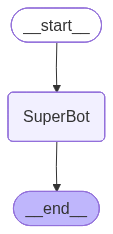

In [81]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [82]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is SAUMYA And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is SAUMYA And I like cricket', additional_kwargs={}, response_metadata={}, id='d703bc81-7430-41bb-a804-cd4f96892d6a'),
  AIMessage(content="Hello Saumya, nice to meet you. Cricket is an exciting sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 47, 'total_tokens': 99, 'completion_time': 0.142112818, 'completion_tokens_details': None, 'prompt_time': 0.005198318, 'prompt_tokens_details': None, 'queue_time': 0.161303062, 'total_time': 0.147311136}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee138-7d1a-7ff0-9646-c2d9cbbf5d65-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_to

# Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is saumya And I like cricket"},config,stream_mode="updates"):#steaming mode updaate only provide last message
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Saumya, nice to meet you. Cricket is an exciting sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 47, 'total_tokens': 99, 'completion_time': 0.162789696, 'completion_tokens_details': None, 'prompt_time': 0.006231941, 'prompt_tokens_details': None, 'queue_time': 0.054629429, 'total_time': 0.169021637}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee14b-b451-7873-b110-ca2eae4d0e1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 52, 'total_tokens': 99})]}}


In [87]:
for chunk in graph_builder.stream({'messages':"what is my name"},config,stream_mode="values"): #straming mode values provide the whole appended message
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is saumya And I like cricket', additional_kwargs={}, response_metadata={}, id='749c8451-0480-43f6-9b9c-53f44b6f78e3'), AIMessage(content="Hi Saumya, nice to meet you. Cricket is an exciting sport, isn't it? Which team or player is your favorite? Do you have a favorite format of the game, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 47, 'total_tokens': 99, 'completion_time': 0.162789696, 'completion_tokens_details': None, 'prompt_time': 0.006231941, 'prompt_tokens_details': None, 'queue_time': 0.054629429, 'total_time': 0.169021637}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee14b-b451-7873-b110-ca2eae4d0e1e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens'

In [88]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Krish, nice to meet you. Cricket is an exciting sport, isn't it? What do you like most about cricket? Are you a fan of a particular team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 45, 'total_tokens': 83, 'completion_time': 0.112946136, 'completion_tokens_details': None, 'prompt_time': 0.001959414, 'prompt_tokens_details': None, 'queue_time': 0.049606676, 'total_time': 0.11490555}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee150-8fad-74a3-bc34-de62fa4edfde-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 38, 'total_tokens': 83})]}}


In [89]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='8e5a199f-8767-4cf2-a3a6-2e0c82e9c14d'), AIMessage(content="Hi Krish, nice to meet you. Cricket is an exciting sport, isn't it? What do you like most about cricket? Are you a fan of a particular team or player?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 45, 'total_tokens': 83, 'completion_time': 0.112946136, 'completion_tokens_details': None, 'prompt_time': 0.001959414, 'prompt_tokens_details': None, 'queue_time': 0.049606676, 'total_time': 0.11490555}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee150-8fad-74a3-bc34-de62fa4edfde-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 38, 'total_tokens': 83}), HumanMessag

In [90]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is saumya and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is saumya and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ee153-958d-7c70-9dad-e781afbfd07d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is saumya and I like to play cricket', additional_kwargs={}, response_metadata={}, id='50232b88-f77b-4f0f-a484-51ba1d4b909e')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ee153-958e-7f60-a4c1-0456256456ec', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:8471162a-a59d-71ef-1444-564ff68f5d2a'}, 'parent_ids': ['019ee153-958d-7c70-9dad-e781afbfd07d']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages